# Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load Dataset

In [7]:
data = pd.read_csv('/content/adult_dataset (1).csv')

In [8]:
# Shape of dataset
print(data.shape)

(48842, 15)


In [9]:
# First 5 rows
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [10]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [11]:
# Statistical summary
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Handle Duplicates

In [12]:
# Check duplicate rows
print('Duplicate rows :', data.duplicated().sum())

Duplicate rows : 16


In [13]:
#Remove duplicates
data = data.drop_duplicates()

In [14]:
# Verify again
print('Duplicate rows after removal :', data.duplicated().sum())

Duplicate rows after removal : 0


# Separate Numerical and Categorical Columns

In [15]:
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print('Numerical Columns')
print(num_cols)

Numerical Columns
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [16]:
print('Numerical Columns')
print(num_cols)

Numerical Columns
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [17]:
print('\nCategorical Columns')
print(cat_cols)


Categorical Columns
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


# Missing Value Analysis

In [18]:
# Count missing values
data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [19]:
# Missing value percentage
missing_percentage = (data.isna().sum() / len(data)) * 100
missing_percentage.sort_values(ascending=False)

,0
workclass,6.885676
occupation,6.875435
native-country,5.540081
hours-per-week,5.001434
age,5.001434
fnlwgt,0.000000
education,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000


# Distribution of Numerical Columns

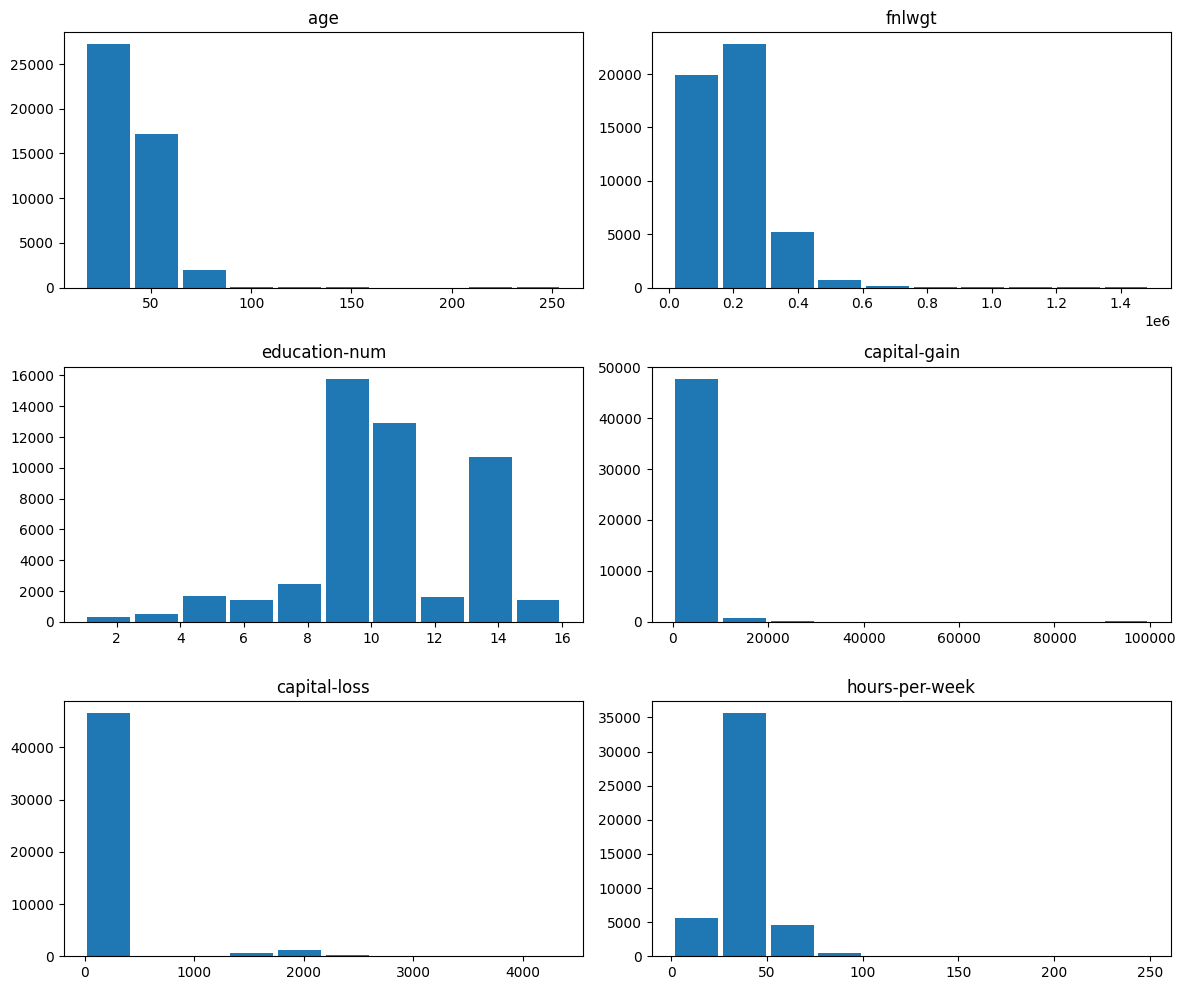

In [20]:
plt.figure(figsize=(12,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    plt.hist(data[col], rwidth=0.9)
    plt.title(col)

plt.tight_layout()
plt.show()

# Handle Missing Values

In [21]:
# Numerical columns are skewed
# So median is preferred

data = data.fillna(data[num_cols].median())

In [22]:
# Fill categorical missing values using mode

data = data.fillna(data[cat_cols].mode().iloc[0])

In [23]:
# Verify again
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Explore Categorical Columns

In [24]:
for col in cat_cols:
    print('\n', col)
    print(data[col].value_counts())


 workclass
workclass
Private             35567
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

 education
education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64

 marital-status
marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 occupation
occupation
Prof-specialty     

# Percentage Distribution of Categories

In [25]:
for col in cat_cols:
    print('\n', col)
    print(data[col].value_counts(normalize=True) * 100)


 workclass
workclass
Private             72.844386
Self-emp-not-inc     7.473477
Local-gov            6.088969
State-gov            3.844263
?                    3.610781
Self-emp-inc         3.326097
Federal-gov          2.756728
Without-pay          0.036866
Never-worked         0.018433
Name: proportion, dtype: float64

 education
education
HS-grad         32.318847
Some-college    22.270921
Bachelors       16.427723
Masters          5.441773
Assoc-voc        4.219064
11th             3.711138
Assoc-acdm       3.278991
10th             2.844796
7th-8th          1.955925
Prof-school      1.708106
9th              1.548355
12th             1.343546
Doctorate        1.216565
5th-6th          1.040429
1st-4th          0.503830
Preschool        0.169991
Name: proportion, dtype: float64

 marital-status
marital-status
Married-civ-spouse       45.830091
Never-married            32.984475
Divorced                 13.580879
Separated                 3.133576
Widowed                   3.1089

# Replace '?' Values

In [26]:
# Replace ? with NaN

data = data.replace('?', np.nan)

In [27]:
# Check null values
data.isna().sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [28]:
# Drop rows having NaN values
# Since percentage is low

data.dropna(inplace=True)

In [29]:
# Verify again
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Outlier Detection

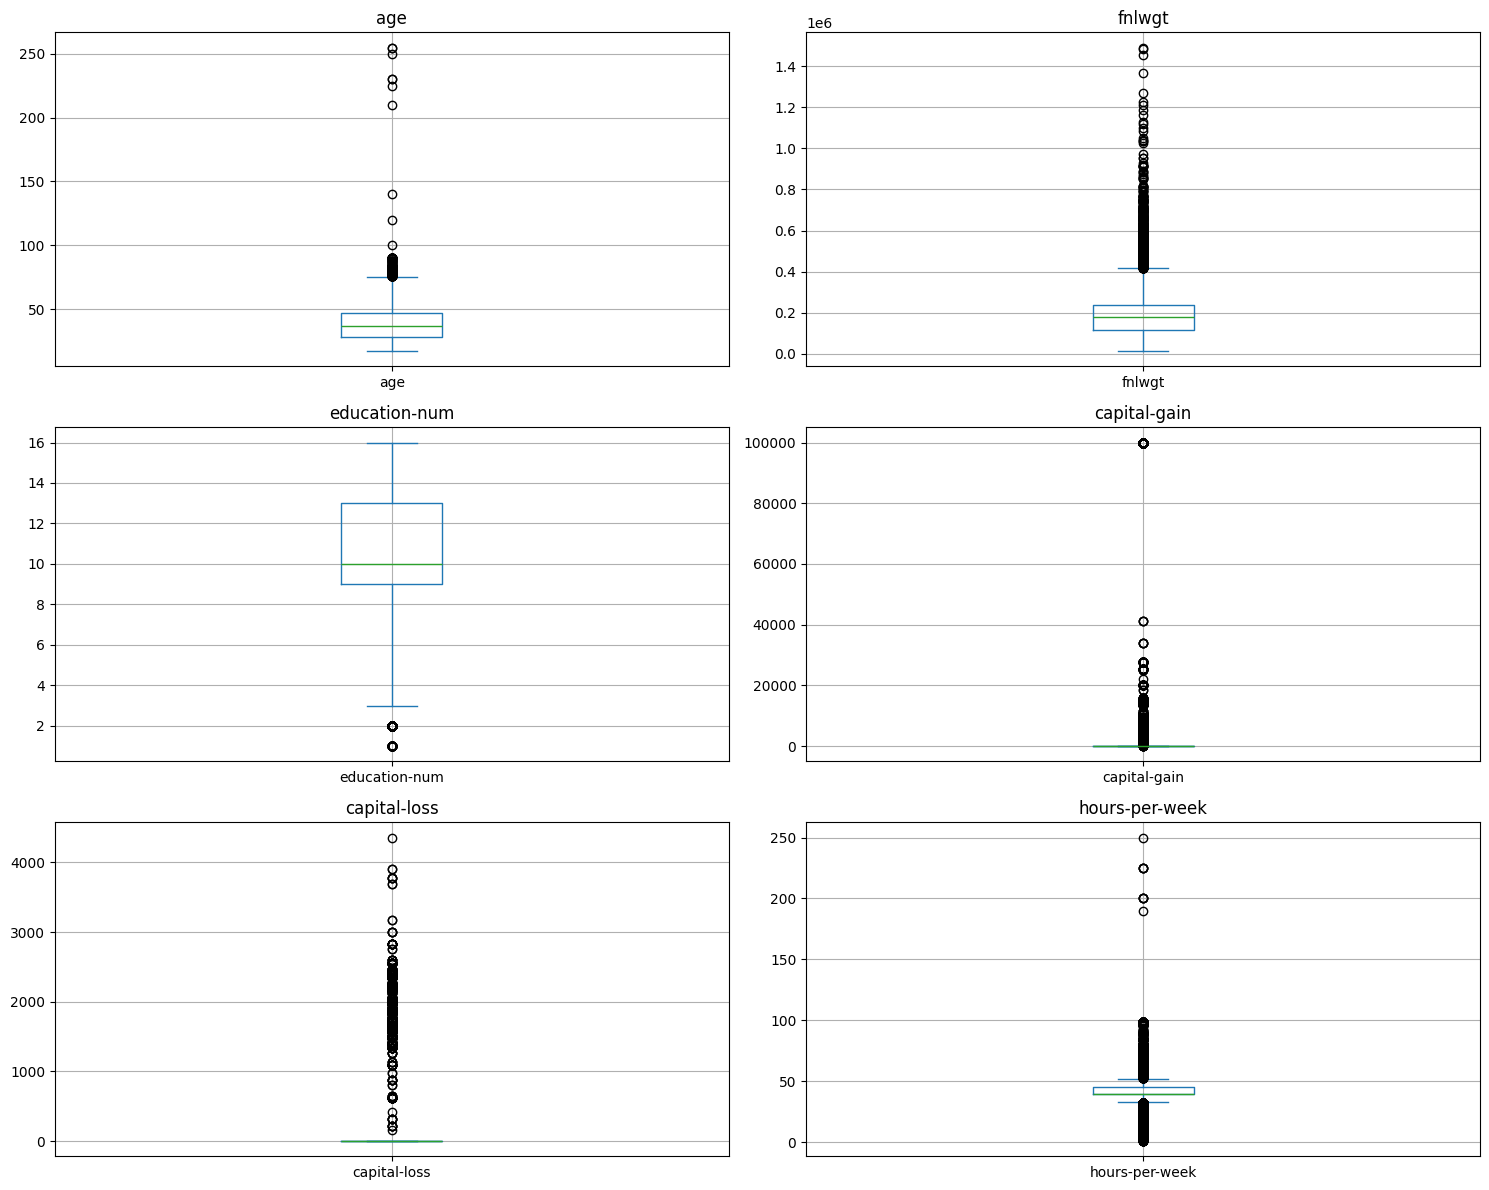

In [30]:
plt.figure(figsize=(15,12))

for i, col in enumerate(num_cols, 1):
    ax = plt.subplot(3,2,i)
    data[col].plot(kind='box', ax=ax)
    plt.title(col)
    plt.grid()

plt.tight_layout()
plt.show()

# IQR Method for Outliers

In [31]:
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)


# Identify outliers
outliers = ((data[num_cols] > upper_limit) |
            (data[num_cols] < lower_limit)).any(axis=1)

outliers_df = data[outliers]

outlier_percent = (len(outliers_df) / len(data)) * 100

print('Percentage of outliers :', outlier_percent)

# Outlier percentage column wise
outlier_counts = ((data[num_cols] > upper_limit) |
                  (data[num_cols] < lower_limit)).mean() * 100

print(outlier_counts.sort_values(ascending=False))

Percentage of outliers : 37.9574614655989
hours-per-week    25.482218
capital-gain       8.318264
capital-loss       4.718850
fnlwgt             2.962198
education-num      0.658745
age                0.635064
dtype: float64


# Cap Small Outliers

In [32]:
# Columns with fewer outliers
cols_to_cap = ['age', 'fnlwgt', 'education-num']

# Apply clipping

data[cols_to_cap] = data[cols_to_cap].clip(lower_limit,
                                           upper_limit,
                                           axis=1)

# Log Transformation

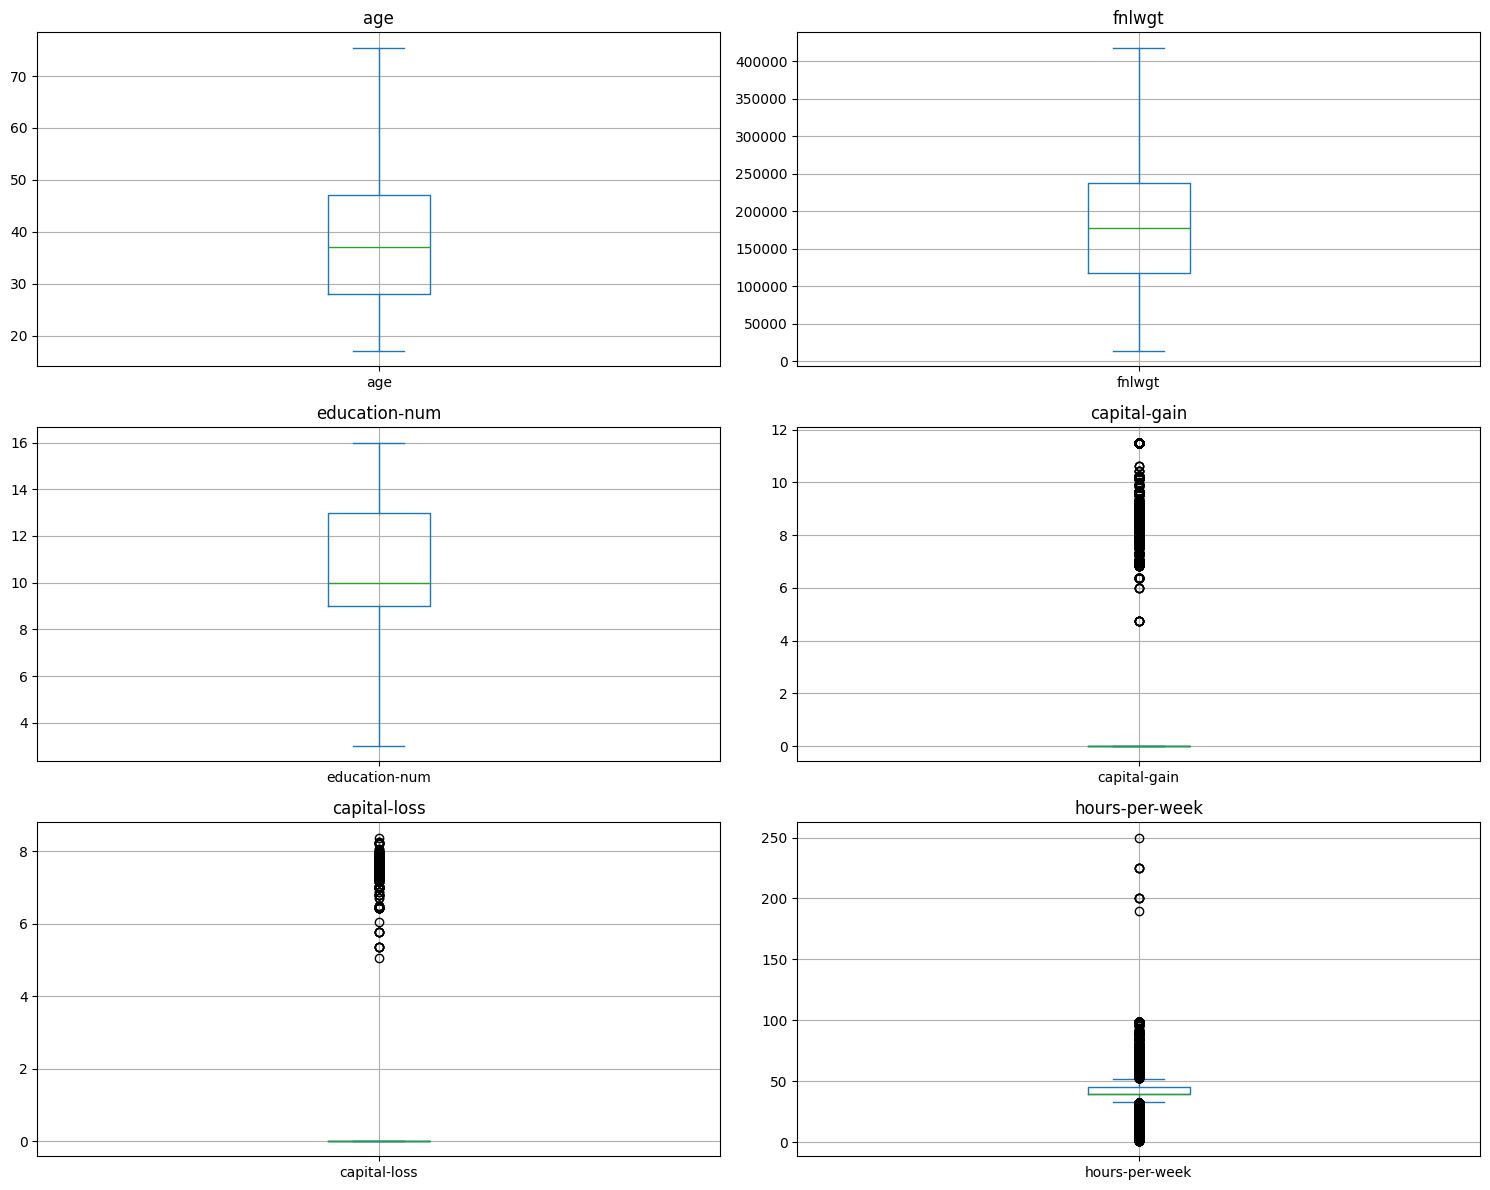

In [33]:
# Apply log transformation
# Helps reduce skewness

cols_to_log = ['capital-gain', 'capital-loss']

for col in cols_to_log:
    data[col] = np.log1p(data[col])

# Boxplot after transformation
plt.figure(figsize=(15,12))

for i, col in enumerate(num_cols, 1):
    ax = plt.subplot(3,2,i)
    data[col].plot(kind='box', ax=ax)
    plt.title(col)
    plt.grid()

plt.tight_layout()
plt.show()




### Handle Unrealistic Working Hours

In [34]:
# Replace values greater than 100
# 250 hours/week is unrealistic

data['hours-per-week'] = np.where(
    data['hours-per-week'] > 100,
    np.nan,
    data['hours-per-week']
)

# Check null values again
data.isna().sum()

# Drop new null values

data.dropna(inplace=True)

# Final null value check

data.isna().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Correlation Analysis

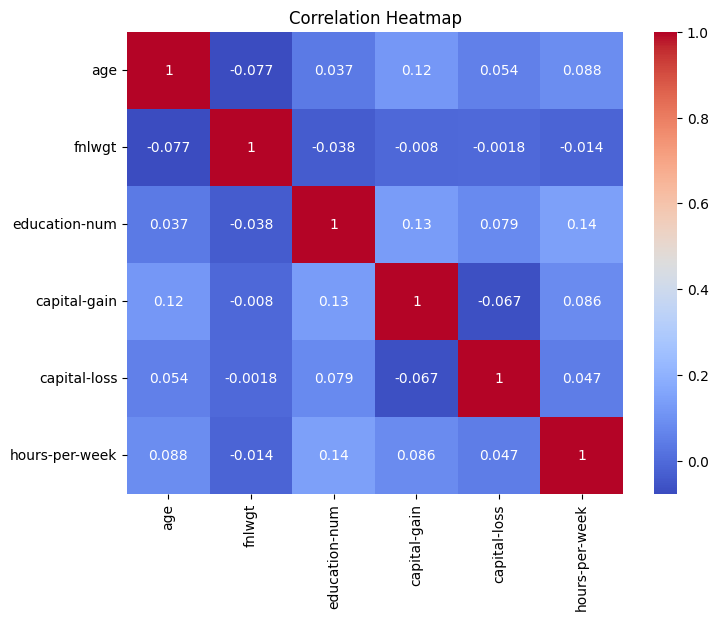

In [35]:
corr_matrix = data[num_cols].corr(method='pearson')

corr_matrix

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True)

plt.title('Correlation Heatmap')
plt.show()

### Remove Unwanted Columns

In [36]:
# fnlwgt has low correlation

data.drop('fnlwgt', axis=1, inplace=True)

# Update num_cols
num_cols = num_cols.drop('fnlwgt')

# education and education-num represent similar information

data.drop('education', axis=1, inplace=True)

cat_cols = cat_cols.drop('education')

# Income not needed for clustering

data.drop('income', axis=1, inplace=True)

cat_cols = cat_cols.drop('income')

data.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country'],
      dtype='object')

# Scaling Numerical Features

In [37]:
# Before scaling

data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,46442.000000,46442.000000,46442.000000,46442.000000,46442.000000
mean,38.447795,10.113669,0.734704,0.354362,40.692993
std,12.962627,2.530931,2.456286,1.593407,11.843214
min,17.000000,3.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,75.500000,16.000000,11.512925,8.379539,99.000000


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale numerical columns

data[num_cols] = scaler.fit_transform(data[num_cols])

# Display a sample of the scaled numerical data to confirm the operation
print("Sample of scaled numerical data after processing:")
print(data[num_cols].head())

Sample of scaled numerical data after processing:
        age  education-num  capital-gain  capital-loss  hours-per-week
0  0.042600       1.140435      2.829538     -0.222395       -0.058515
1  0.891203       1.140435     -0.299115     -0.222395       -2.338326
2 -0.034545      -0.440028     -0.299115     -0.222395       -0.058515
3  1.122640      -1.230260     -0.299115     -0.222395       -0.058515
4 -0.806002       1.140435     -0.299115     -0.222395       -0.058515


In [39]:
# After scaling

data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04
mean,-2.695785e-16,2.977297e-16,-3.977889e-18,2.968117e-17,7.037803e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.654605e+00,-2.810723e+00,-2.991150e-01,-2.223953e-01,-3.351575e+00
25%,-8.060023e-01,-4.400281e-01,-2.991150e-01,-2.223953e-01,-5.851459e-02
50%,-1.116911e-01,-4.491229e-02,-2.991150e-01,-2.223953e-01,-5.851459e-02
75%,6.597657e-01,1.140435e+00,-2.991150e-01,-2.223953e-01,3.636726e-01
max,2.858418e+00,2.325783e+00,4.388063e+00,5.036544e+00,4.923295e+00


### Reduce High Cardinality

In [40]:
# Strip spaces

data['native-country'] = data['native-country'].str.strip()

In [41]:
# Group countries

data['native-country'] = np.where(
    data['native-country'] == 'United-States',
    'United-States',
    'Other'
)

### Marital Status Grouping

In [42]:
# Group married classes

data['marital-status'] = data['marital-status'].replace(
    ['Married-civ-spouse',
     'Married-spouse-absent',
     'Married-AF-spouse'],
    'Married'
)

In [43]:
# Group single classes

data['marital-status'] = data['marital-status'].replace(
    ['Never-married',
     'Divorced',
     'Separated',
     'Widowed'],
    'Single'
)

### Workclass Grouping

In [44]:
workclass_map = {
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Self-emp-not-inc': 'Self-Employed',
    'Self-emp-inc': 'Self-Employed',
    'Without-pay': 'Other',
    'Never-worked': 'Other'
}

In [45]:
# Apply mapping

data['workclass'] = data['workclass'].replace(workclass_map)

In [46]:
# Check categories
for col in cat_cols:
    print('\n', col)
    print(data[col].unique())


 workclass
['Government' 'Self-Employed' 'Private' 'Other']

 marital-status
['Single' 'Married']

 occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Transport-moving' 'Farming-fishing'
 'Machine-op-inspct' 'Tech-support' 'Craft-repair' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']

 relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

 race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

 sex
['Male' 'Female']

 native-country
['United-States' 'Other']


# One Hot Encoding

In [47]:
encoded_data = pd.get_dummies(
    data,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

In [48]:
encoded_data.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Other,workclass_Private,workclass_Self-Employed,marital-status_Single,occupation_Armed-Forces,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States
0,0.042600,1.140435,2.829538,-0.222395,-0.058515,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,1
1,0.891203,1.140435,-0.299115,-0.222395,-2.338326,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
2,-0.034545,-0.440028,-0.299115,-0.222395,-0.058515,0,1,0,1,0,...,0,0,0,0,0,0,0,1,1,1
3,1.122640,-1.230260,-0.299115,-0.222395,-0.058515,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,-0.806002,1.140435,-0.299115,-0.222395,-0.058515,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [49]:
encoded_data.shape

(46442, 33)

# PCA for Dimensionality Reduction

In [50]:
# Fit PCA on all components

pca_full = PCA(n_components=encoded_data.shape[1])

pca_full.fit(encoded_data)

PCA(n_components=33)

In [51]:
# Cumulative variance

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

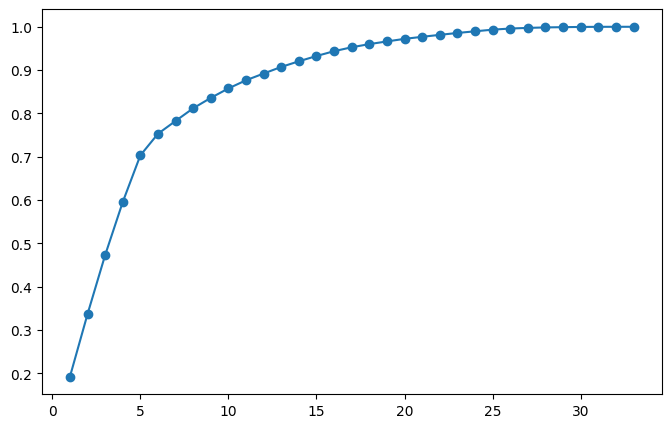

In [52]:
# Plot cumulative variance

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

In [54]:
# Choose components with 95% variance

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print('Number of components selected :', n_components)

Number of components selected : 17


In [55]:
# Apply PCA

pca = PCA(n_components=n_components)

pca_data = pca.fit_transform(encoded_data)

In [56]:
# Shape after PCA

pca_data.shape

(46442, 17)

# Elbow Method for KMeans

In [57]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(pca_data)

    wcss.append(kmeans.inertia_)

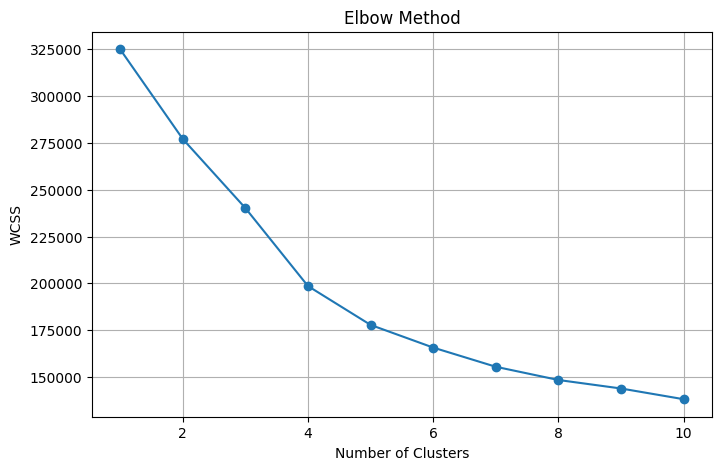

In [58]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid()
plt.show()


# KMeans Clustering

In [59]:
# Assume optimal clusters = 6

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

In [60]:
# Fit model

kmeans.fit(pca_data)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [61]:
# Predict clusters

kmeans_labels = kmeans.predict(pca_data)

kmeans_labels

array([4, 1, 2, ..., 5, 4, 5], dtype=int32)

In [62]:
# Add cluster labels to dataframe

encoded_data['KMeans_Cluster'] = kmeans_labels

In [63]:
encoded_data.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Other,workclass_Private,workclass_Self-Employed,marital-status_Single,occupation_Armed-Forces,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States,KMeans_Cluster
0,0.042600,1.140435,2.829538,-0.222395,-0.058515,0,0,0,1,0,...,0,0,0,0,0,0,1,1,1,4
1,0.891203,1.140435,-0.299115,-0.222395,-2.338326,0,0,1,0,0,...,0,0,0,0,0,0,1,1,1,1
2,-0.034545,-0.440028,-0.299115,-0.222395,-0.058515,0,1,0,1,0,...,0,0,0,0,0,0,1,1,1,2
3,1.122640,-1.230260,-0.299115,-0.222395,-0.058515,0,1,0,0,0,...,0,0,0,0,1,0,0,1,1,1
4,-0.806002,1.140435,-0.299115,-0.222395,-0.058515,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,5


# Silhouette Score for KMeans

In [64]:
score = silhouette_score(pca_data, kmeans_labels)

print('Silhouette Score :', score)

Silhouette Score : 0.1777496258996257


# Agglomerative Clustering

In [65]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=17)

# Transform data
pca_data = pca.fit_transform(encoded_data)

# Check shape
print(pca_data.shape)

(46442, 17)


In [66]:
# Train Agglomerative Model

sample_size = 10000

# Randomly select 10000 rows from PCA data
indices = np.random.choice(
    len(pca_data),
    sample_size,
    replace=False
)

# Create sample dataset
pca_sample = pca_data[indices]

# Create Agglomerative Clustering model
agglo = AgglomerativeClustering(
    n_clusters=6
)

# Train model and get cluster labels
agglo_labels = agglo.fit_predict(pca_sample)

# Display cluster labels
print(agglo_labels)

[2 0 5 ... 0 4 4]


# Silhouette Score for Agglomerative Clustering

In [67]:
# Silhouette Score for Agglomerative Clustering

from sklearn.metrics import silhouette_score

agglo_score = silhouette_score(
    pca_sample,
    agglo_labels
)

print('Agglomerative Silhouette Score :', agglo_score)

Agglomerative Silhouette Score : 0.2889567483383789


# Visualize Clusters

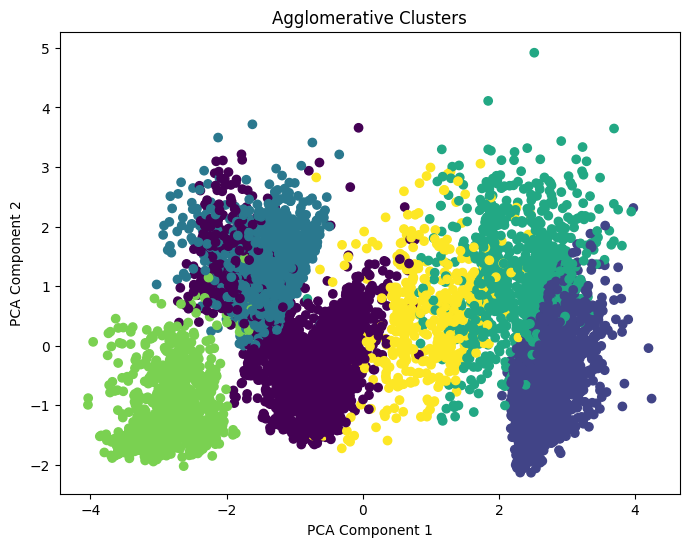

In [70]:
# PCA Visualization for Agglomerative Clustering

plt.figure(figsize=(8,6))

plt.scatter(
    pca_sample[:,0],
    pca_sample[:,1],
    c=agglo_labels
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Agglomerative Clusters')

plt.show()

In [71]:
# Check cluster distribution

print(pd.Series(agglo_labels).value_counts())

0    3872
1    2166
2    1611
4    1063
3     822
5     466
Name: count, dtype: int64


# Interpretation, Insights & Policy Recommendations

# Step 13: Interpretation, Insights & Policy Recommendations

## Cluster 0: Young Early-Career Population
### Characteristics
- Average age: ~25 years
- Mostly never married
- Lower working hours (~38/week)
- Education: Some college
- Relationship status: Own-child
- Very low capital gain
- Mostly lower-income population (>98% <=50K)

### Interpretation
This cluster represents young adults and early-career individuals, including students, recent graduates, and financially emerging workers.

### Recommended Policy Actions
**Upskilling Programs**
- Career readiness programs
- Technical skill development
- Internship and job placement initiatives

**Financial Aid / Inclusion Efforts**
- Education support
- Affordable housing support
- Youth employment schemes

# Cluster 1: Specialized Working Population

### Characteristics
- Average age: ~39 years
- Mostly married
- Higher work hours (~42/week)
- Occupation: Protective services
- Moderate higher-income percentage (~31%)

### Interpretation
This cluster appears to represent stable working-class professionals such as protective service employees and government workers.

### Recommended Policy Actions
**Tax Reform**
- Middle-income tax benefits
- Retirement savings incentives

**Upskilling Programs**
- Career advancement programs
- Leadership training

## Cluster 2: Middle-Class Workforce

### Characteristics
- Average age: ~39 years
- Mostly never married
- Moderate work hours (~41/week)
- Education: High school graduate
- Moderate professional occupations
- Mostly <=50K income (~91%)

### Interpretation
This cluster represents lower-middle or middle-income working adults with stable employment but limited financial growth.

### Recommended Policy Actions
**Upskilling Programs**
- Reskilling initiatives
- Digital literacy training
- Professional certification support

**Financial Inclusion**
- Financial literacy campaigns
- Savings and investment education

## Cluster 3: High-Earning Established Adults

### Characteristics
- Average age: ~43 years
- Highest capital gain and loss
- Highest working hours (~43/week)
- Mostly married
- Highest >50K population (~45%)

### Interpretation
This cluster represents financially established professionals and experienced working adults.

### Recommended Policy Actions
**Tax Reform**
- Retirement tax incentives
- Investment planning support

**Financial Planning**
- Wealth management education
- Retirement planning programs

## Key Findings

- Clustering successfully identified hidden socioeconomic groups without using income during training.
- Income patterns naturally emerged across clusters, validating meaningful segmentation.
- Younger and lower-income groups would benefit more from upskilling and financial inclusion programs.
- Higher-income established groups may benefit more from tax and investment-related policies.

Step 14: KMeans vs Agglomerative Clustering Comparison

| Aspect | KMeans | Agglomerative |
|--------|---------|---------------|
| Speed | Faster | Slower |
| Scalability | Better for large datasets | Poor for large datasets |
| Cluster Shape | Best for spherical clusters | Can capture hierarchical relationships |
| Computational Cost | Low | High |
| Dataset Suitability | Better for Adult Census dataset | Used on sampled PCA data |

### Conclusion
KMeans was selected as the primary clustering algorithm because it handled the full dataset efficiently and produced meaningful clusters with reasonable silhouette scores.

Agglomerative clustering was used mainly for hierarchical comparison and visualization on sampled PCA data due to computational limitations.

# Step 15: Final Conclusion

This project successfully identified hidden socioeconomic groups in the U.S. adult population using unsupervised learning techniques.

KMeans clustering identified meaningful population segments based on demographics, education, occupation, and work habits without using income labels during training.

Cluster profiling revealed clear socioeconomic differences, with some groups showing lower earning potential and requiring upskilling or financial support, while others represented financially established populations who may benefit more from tax and investment policies.

The findings demonstrate how clustering techniques can help policymakers design targeted welfare, employment, and financial inclusion programs.